# 1.4 BayesianBrightnessInference

Bu notebook, Makine Ogrenmesi 4. Odev.pdf icin Bayesyen parlaklik analizi teslimidir. Ayni mantik `bayesian_brightness_analysis.py` icinde tutulur; notebook burada sonuclari uretir ve yorumlar.

In [1]:
import pandas as pd
from IPython.display import Image, Markdown, display

from bayesian_brightness_analysis import run_full_analysis

bundle = run_full_analysis()
results = bundle['results']
analysis_text = bundle['analysis_text']
figure_paths = bundle['figure_paths']
constants = bundle['constants']

display(Markdown('## Deney Sabitleri'))
display(pd.DataFrame([constants]))

display(Markdown('## Veri Onizlemesi'))
display(pd.DataFrame({'gozlem': bundle['data_preview']}))


## Deney Sabitleri

,true_mu,true_sigma,n_obs,seed,initial,n_walkers,n_steps,burn_in,thin
0,150.0,10.0,50,42,"[140.0, 5.0]",32,2000,500,15


## Veri Onizlemesi

,gozlem
0,154.967142
1,148.617357
2,156.476885
3,165.230299
4,147.658466
5,147.658630
6,165.792128
7,157.674347
8,145.305256
9,155.425600


In [2]:
display(Markdown('## 5.1 Parametre Karsilastirma Tablosu'))
display(pd.DataFrame(bundle['base_table_rows']))

display(Markdown('## Acceptance Fraction'))
display(pd.DataFrame([
    {
        'Senaryo': result.label,
        'Acceptance Fraction': result.acceptance_fraction,
    }
    for result in results.values()
]))


## 5.1 Parametre Karsilastirma Tablosu

,Degisken,Gercek Deger,Tahmin Edilen (Median),Alt Sinir (%16),Ust Sinir (%84),Mutlak Hata
0,mu (Parlaklik),150.0,147.749833,146.374242,149.121552,2.250167
1,sigma (Hata Payi),10.0,9.486637,8.625949,10.484058,0.513363


## Acceptance Fraction

,Senaryo,Acceptance Fraction
0,"Temel senaryo (n=50, genis prior)",0.708688
1,"Prior etkisi (n=50, dar mu prior'i)",0.658797
2,"Veri miktari etkisi (n=5, genis prior)",0.677687


## Uretilen Grafikler

### Temel corner plot

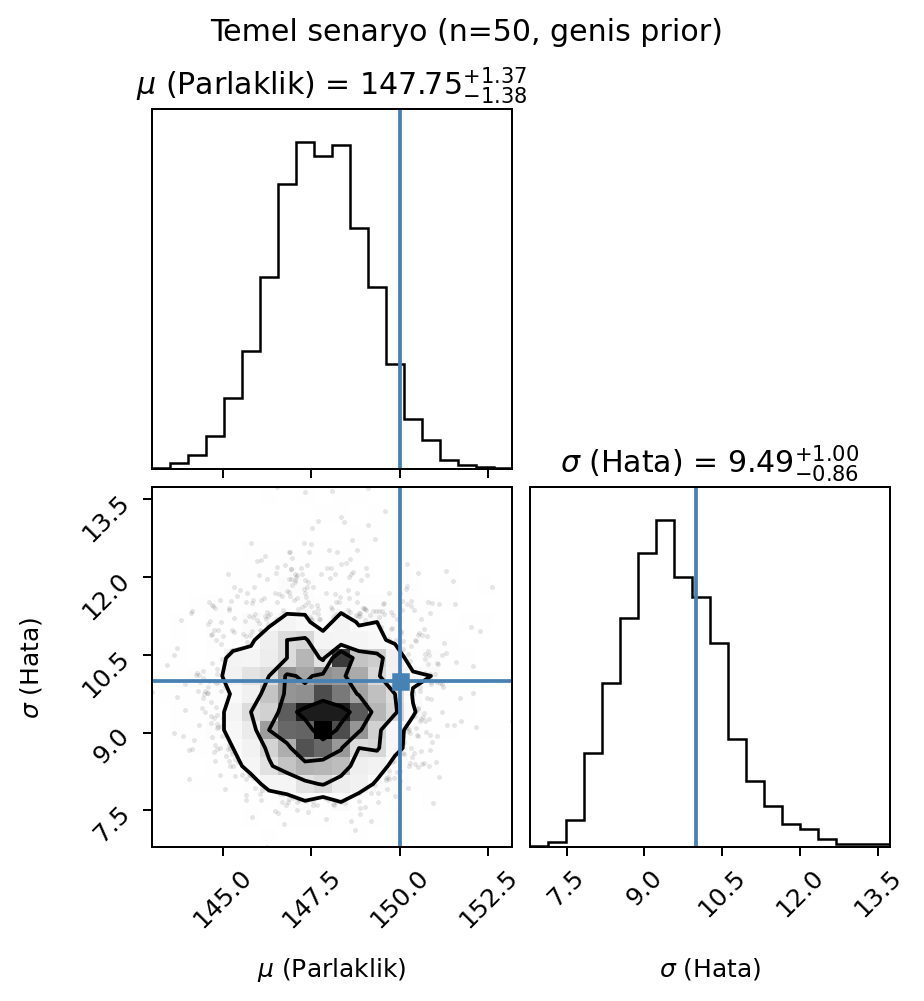

### Temel trace plot

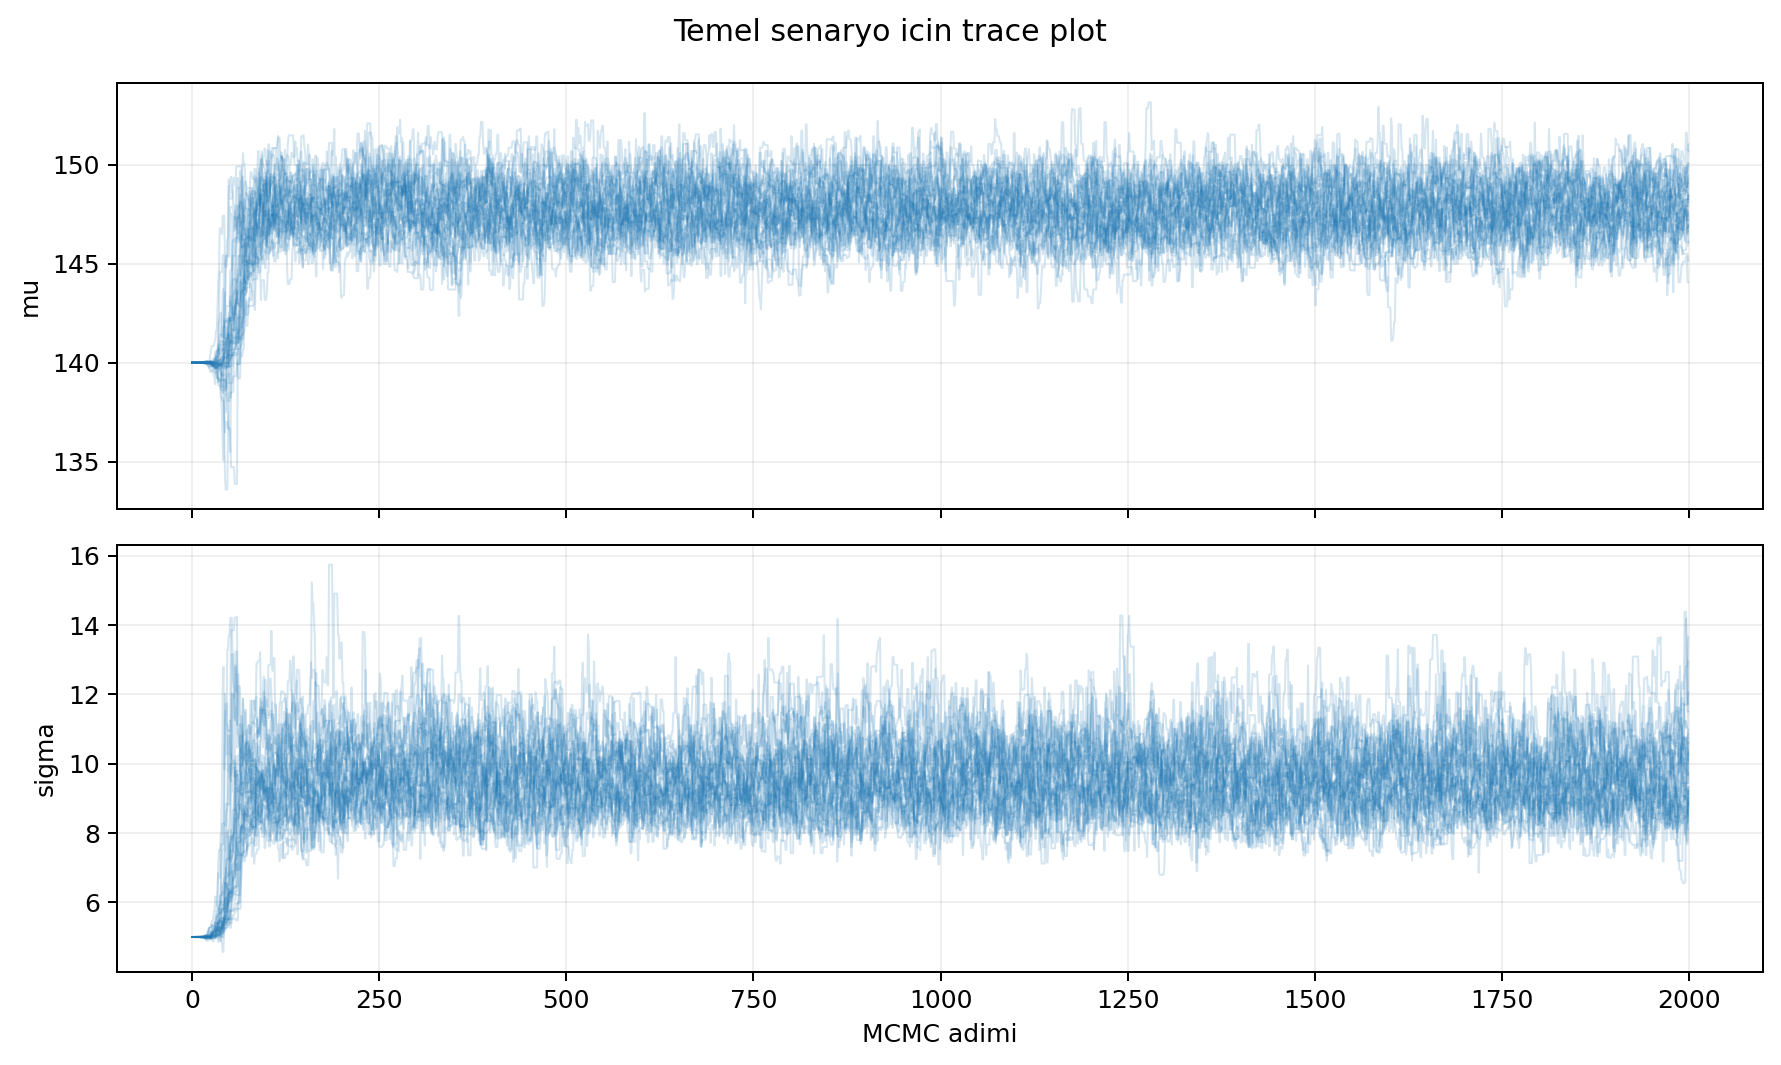

### Dar prior etkisi

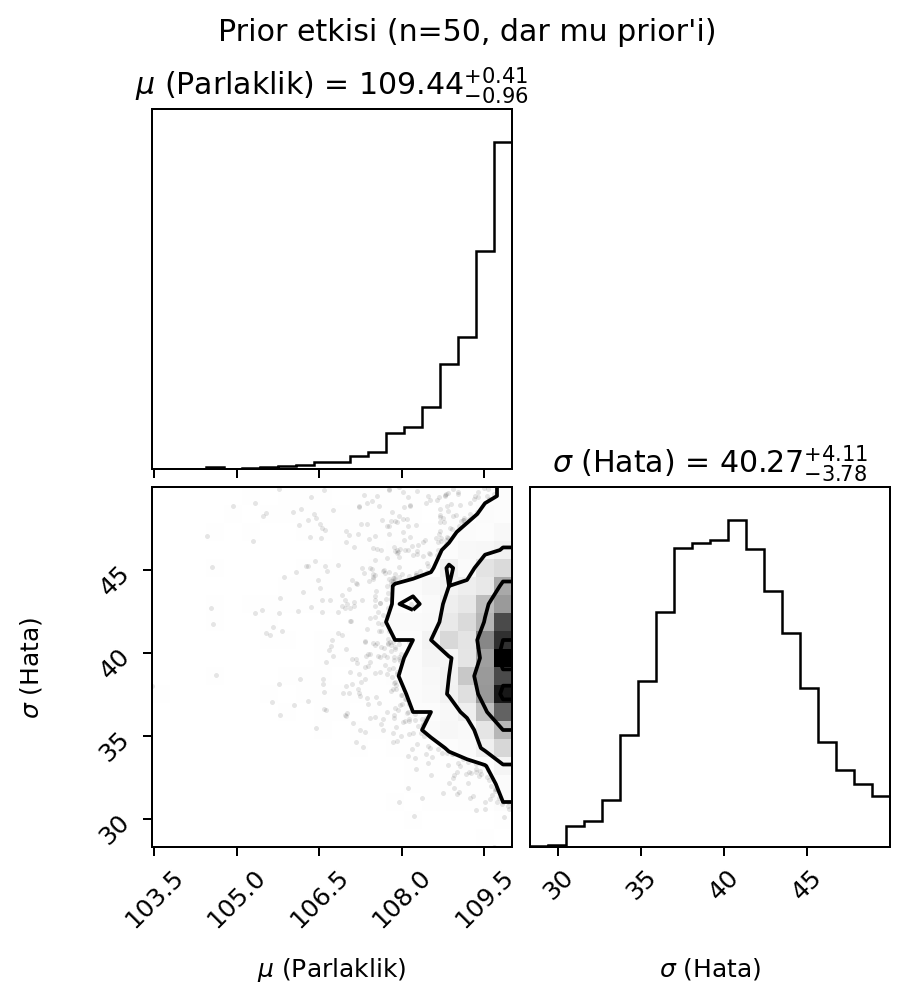

### Az veri senaryosu

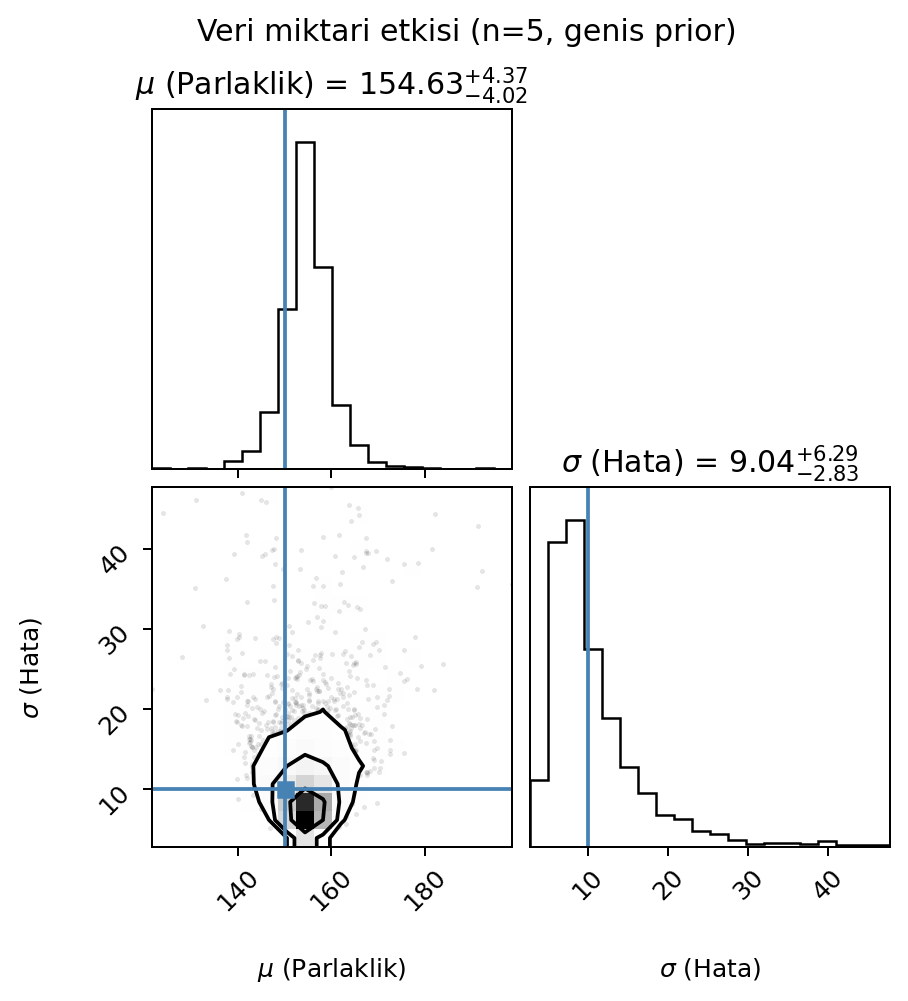

### Senaryo karsilastirma ozeti

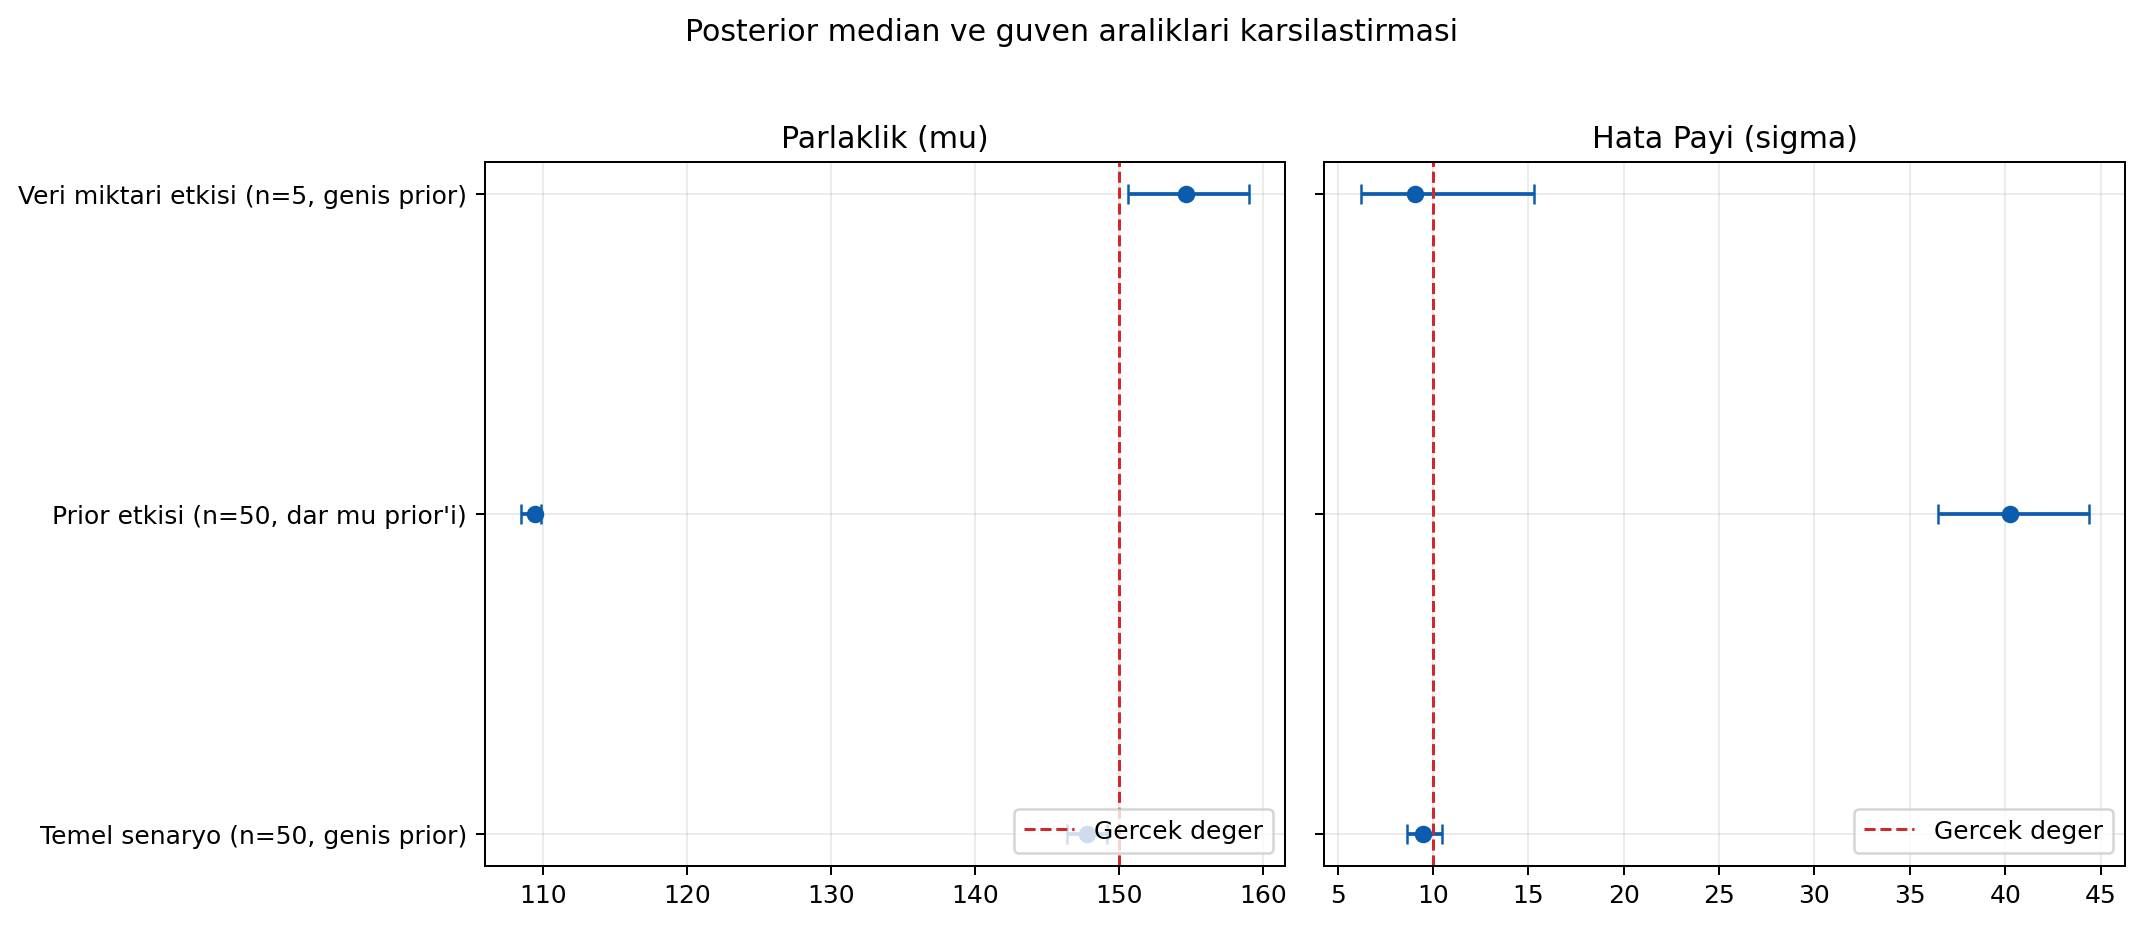

In [3]:
display(Markdown('## Uretilen Grafikler'))
for title, key in [
    ('Temel corner plot', 'base_corner'),
    ('Temel trace plot', 'base_trace'),
    ('Dar prior etkisi', 'prior_corner'),
    ('Az veri senaryosu', 'sample_size_corner'),
    ('Senaryo karsilastirma ozeti', 'comparison'),
]:
    display(Markdown(f'### {title}'))
    display(Image(filename=str(figure_paths[key])))


In [4]:
display(Markdown('## Analiz Sorularina Cevaplar'))
answer_order = [
    ('Temel modelin accuracy yorumu', 'accuracy'),
    ('Prior etkisi', 'prior_effect'),
    ('Veri miktari etkisi', 'sample_size'),
    ('Neden mu daha hassas?', 'precision'),
    ('Corner plot korelasyon yorumu', 'correlation'),
]
for heading, key in answer_order:
    display(Markdown(f'### {heading}'))
    display(Markdown(analysis_text[key]))


## Analiz Sorularina Cevaplar

### Temel modelin accuracy yorumu

Temel senaryoda mu icin mutlak hata 2.250, sigma icin mutlak hata 0.513 bulundu. Uretilen verinin ornek ortalamasi 147.745 ve ornek standart sapmasi 9.243 oldugundan posterior merkezleri de bu gozlenen degerlere yaklasti. Bu, Bayesyen modelin gurultulu ama sonlu sayida gozleme uygun davrandigini gosteriyor.

### Prior etkisi

Dar prior senaryosunda mu mediani temel senaryoya gore -38.308 birim kaydi. Bunun nedeni, likelihood veriyi 150 civarina cekse bile prior'in mu'yu 100-110 bandinda tutmaya zorlamasi. Veri prior ile celistikce posterior, iki bilgi kaynagi arasinda bir uzlasma noktasina gelir; ayni nedenle sigma tahmini de 40.266 seviyesine siserek yanlis merkezlenmis modeli telafi etmeye calisir.

...

n_obs=5 senaryosunda mu icin guven araligi genisligi 3.05x, sigma icin 4.91x buyudu. Daha az veri, posterior dagilimin daralmasi icin yeterli kanit saglayamadigindan belirsizlik artiyor.

### Neden mu daha hassas?

Temel senaryoda mu icin goreli guven araligi genisligi %1.83, sigma icin %18.58. Ortalama tahmini, verinin merkezine dogrudan bagli oldugu ve standart hata yaklasik sigma/sqrt(n) ile azaldigi icin genellikle daha kesin olur. Varyans veya sigma tahmini ise karesel sapmalara dayandigindan ve uc degerlere daha hassas oldugundan goreli olarak daha genis posterior verir. n=50 bu farki belirginlestirir.

### Corner plot korelasyon yorumu

Temel corner plot'taki ortak dagilim neredeyse dik bir elips beklentisine uygundur ve ornek korelasyon katsayisi 0.023 bulundu. Bu, parlaklik ve hata tahminlerinin belirgin bir korelasyon gostermiyor anlamina gelir; yani bir parametredeki degisim digerini tamamen bagimsiz birakmiyor ama guclu bir bagimlilik da yok.